# 01 — Exploratory Data Analysis

This notebook explores:
1. **CNN/Daily Mail** — the corpus used for BART two-stage fine-tuning
2. **Processed NewsAPI articles** — the live-mode pipeline input

## Contents
1. CNN/DM: load and sample (5K per split)
2. CNN/DM: derive headline and summary targets
3. CNN/DM: length distributions and percentile tables
4. CNN/DM: boilerplate / prefix frequency
5. CNN/DM: sample inspection
6. NewsAPI: category, source, length breakdown
7. Findings summary

In [1]:
import glob
import json
import os
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

/Users/sai/NEU/NLP/NewsForge/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. CNN/Daily Mail — Load and Sample

Loading the `abisee/cnn_dailymail` v3.0.0 mirror and taking the first 5,000 examples from each split.

In [2]:
N_PER_SPLIT = 5000

splits = {}
for split in ['train', 'validation', 'test']:
    ds = load_dataset('abisee/cnn_dailymail', '3.0.0', split=split, streaming=True)
    rows = []
    for i, ex in enumerate(ds):
        if i >= N_PER_SPLIT:
            break
        rows.append({'id': ex['id'], 'article': ex['article'], 'highlights': ex['highlights']})
    splits[split] = pd.DataFrame(rows)
    print(f'{split}: {len(splits[split])} examples')

splits['train'].head(2)

train: 5000 examples


validation: 5000 examples


test: 5000 examples


,id,article,highlights
0,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...
1,ee8871b15c50d0db17b0179a6d2beab35065f1e9,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...


## 2. Derive Headline and Summary Targets

**Important EDA finding (see §4):** CNN/DM v3.0.0 articles contain **no newlines** — the entire article body is one paragraph. So instead of "first line" we split on the **first sentence boundary** (`. `, `! `, `? ` followed by whitespace + capital).

- **Headline** = first sentence of `article`, with the literal `(CNN) -- ` prefix stripped if present.
- **Summary target** = full `highlights` with newlines collapsed to spaces (standard CNN/DM convention).

In [3]:
# Strip rule: `(CNN) -- ` (plain) and `CITY (CNN) -- ` (dateline) variants.
# Optional city prefix: starts with capital, allows letters/spaces/commas/periods/apostrophes/hyphens, up to 40 chars.
CNN_PREFIX_RE = re.compile(r"^\s*(?:[A-Z][A-Za-z .,'\-]{1,40})?\(CNN\)\s*--\s*")
WHITESPACE_RE = re.compile(r'\s+')
SENTENCE_BOUNDARY_RE = re.compile(r'(?<=[.!?])\s+(?=[A-Z0-9"\'])')

def derive_headline(article):
    first_sentence = SENTENCE_BOUNDARY_RE.split(article, maxsplit=1)[0].strip()
    return CNN_PREFIX_RE.sub('', first_sentence).strip()

def derive_summary_target(highlights):
    text = highlights.replace('\n', ' ')
    return WHITESPACE_RE.sub(' ', text).strip()

for split in splits:
    splits[split]['headline'] = splits[split]['article'].map(derive_headline)
    splits[split]['summary_target'] = splits[split]['highlights'].map(derive_summary_target)

splits['train'][['article', 'headline', 'summary_target']].head(3)

,article,headline,summary_target
0,"LONDON, England (Reuters) -- Harry Potter star...","LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...
1,Editor's note: In our Behind the Scenes series...,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...",Drivers who were on the Minneapolis bridge whe...,"NEW: ""I thought I was going to die,"" driver sa..."


## 3. Length Distributions and Percentile Tables

Per-field word counts across all 15K sampled examples.

In [4]:
def word_count(s):
    return len(str(s).split())

all_df = pd.concat(splits.values(), ignore_index=True)
for field in ['article', 'highlights', 'headline', 'summary_target']:
    all_df[f'{field}_wc'] = all_df[field].map(word_count)

pct = [50, 75, 90, 95, 99]
rows = []
for field in ['article', 'highlights', 'headline', 'summary_target']:
    wc = all_df[f'{field}_wc']
    row = {'field': field, 'min': int(wc.min()), 'mean': round(wc.mean(), 1), 'max': int(wc.max())}
    for p in pct:
        row[f'p{p}'] = int(np.percentile(wc, p))
    rows.append(row)
pd.DataFrame(rows).set_index('field')

,min,mean,max,p50,p75,p90,p95,p99
field,,,,,,,,
article,18,586.9,1919,512,777,1039,1231,1577
highlights,9,46.9,574,45,53,64,74,98
headline,1,24.4,131,25,30,35,39,51
summary_target,9,46.9,574,45,53,64,74,98


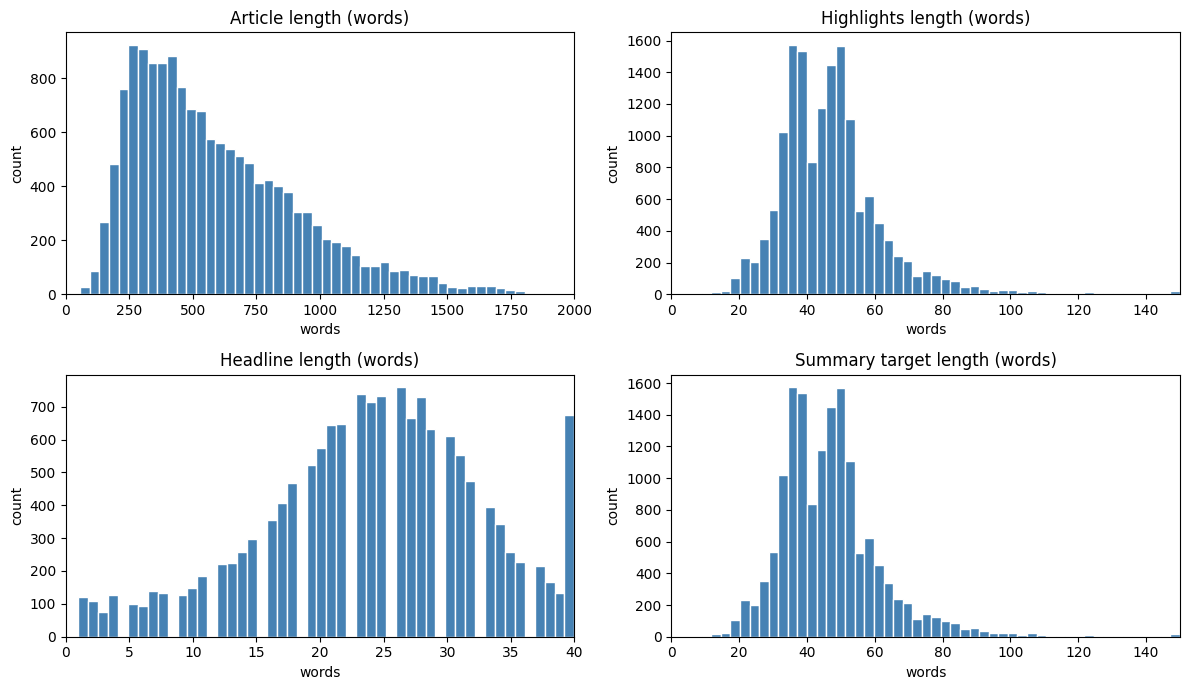

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
configs = [
    ('article_wc', 'Article length (words)', (0, 2000), axes[0][0]),
    ('highlights_wc', 'Highlights length (words)', (0, 150), axes[0][1]),
    ('headline_wc', 'Headline length (words)', (0, 40), axes[1][0]),
    ('summary_target_wc', 'Summary target length (words)', (0, 150), axes[1][1]),
]
for col, label, xlim, ax in configs:
    ax.hist(all_df[col].clip(upper=xlim[1]), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('words')
    ax.set_ylabel('count')
    ax.set_xlim(xlim)
plt.tight_layout()
plt.show()

## 4. Boilerplate / Prefix Frequency

How common is the `(CNN) --` prefix, and what other prefix patterns appear (datelines, Reuters bylines, etc.)?
This informs whether our conservative `(CNN) --`-only strip rule is sufficient or needs expansion.

In [6]:
PREFIX_PATTERNS = {
    '(CNN) -- (plain)': re.compile(r'^\s*\(CNN\)\s*--'),
    'CITY (CNN) -- (dateline)': re.compile(r'^\s*[A-Z][A-Za-z .,]{2,40}\(CNN\)\s*--'),
    '(Reuters) -- (plain)': re.compile(r'^\s*\(Reuters\)\s*--'),
    'CITY, COUNTRY (Reuters) -- (Reuters dateline)': re.compile(r'^\s*[A-Z][A-Za-z .,]{2,60}\(Reuters\)\s*--'),
    'By <Author> starts (byline)': re.compile(r'^\s*By\s+[A-Z]'),
    'ALL-CAPS opening (e.g., WASHINGTON)': re.compile(r'^\s*[A-Z]{3,}(?:\s+[A-Z]{2,})*\s*[,.:]'),
}

prefix_counts = {name: 0 for name in PREFIX_PATTERNS}
for article in all_df['article']:
    first = article.split('\n', 1)[0]
    for name, pat in PREFIX_PATTERNS.items():
        if pat.match(first):
            prefix_counts[name] += 1
total = len(all_df)
summary = pd.DataFrame([
    {'pattern': name, 'count': c, 'pct': round(c / total * 100, 1)}
    for name, c in prefix_counts.items()
]).sort_values('count', ascending=False).reset_index(drop=True)
print(f'Total articles analysed: {total}')
summary

Total articles analysed: 15000


,pattern,count,pct
0,CITY (CNN) -- (dateline),2383,15.9
1,(CNN) -- (plain),2057,13.7
2,"ALL-CAPS opening (e.g., WASHINGTON)",1829,12.2
3,"CITY, COUNTRY (Reuters) -- (Reuters dateline)",14,0.1
4,By <Author> starts (byline),1,0.0
5,(Reuters) -- (plain),0,0.0


## 5. Sample Inspection

10 random examples showing the raw article start, derived headline, and summary target.

In [7]:
sample = all_df.sample(10, random_state=SEED).reset_index(drop=True)
for i, row in sample.iterrows():
    print(f'=== Sample {i+1} (id={row["id"][:10]}) ===')
    print(f'article[:180]: {row["article"][:180]!r}')
    print(f'headline     : {row["headline"]}')
    print(f'summary      : {row["summary_target"][:200]}')
    print(f'wc: article={row["article_wc"]}, headline={row["headline_wc"]}, summary={row["summary_target_wc"]}')
    print()

=== Sample 1 (id=3190e13aaa) ===
article[:180]: 'Ryuichi Kiyonari bettered the Donington Park lap record to take put his Buildbase BMW on to pole start for the Easter Monday opening round of the MCE British Superbike Championship'
headline     : Ryuichi Kiyonari bettered the Donington Park lap record to take put his Buildbase BMW on to pole start for the Easter Monday opening round of the MCE British Superbike Championship.
summary      : Ryuichi Kiyonari bettered the Donington Park lap record on Sunday . Japanese rider powered in a scorching time of one minute 29.455 seconds . Shane Bryne finished less than a quarter of a second downÂ
wc: article=140, headline=30, summary=36

=== Sample 2 (id=0479f93e1a) ===
article[:180]: 'Alan Pardew has called for more consistent punishments after Crystal Palace captain Mile Jedinak was retrospectively banned for four matches. Video footage showed the 30-year-old t'
headline     : Alan Pardew has called for more consistent punishments after Crystal

## 6. NewsAPI — Category, Source, and Length Breakdown

Loading the latest cleaned NewsAPI article dump from `data/processed/newsapi/`.

In [8]:
candidate_paths = [
    'data/processed/newsapi/articles_*.json',
    '../data/processed/newsapi/articles_*.json',
]
newsapi_files = []
for p in candidate_paths:
    found = sorted(glob.glob(p), key=os.path.getmtime)
    if found:
        newsapi_files = found
        break
newsapi_path = newsapi_files[-1]
with open(newsapi_path) as f:
    newsapi_articles = json.load(f)
newsapi_df = pd.DataFrame(newsapi_articles)
print(f'Loaded {len(newsapi_df)} NewsAPI articles from {newsapi_path}')
newsapi_df[['source', 'category', 'title', 'word_count', 'is_paywall_preview']].head(5)

Loaded 335 NewsAPI articles from ../data/processed/newsapi/articles_20260419T205819Z.json


,source,category,title,word_count,is_paywall_preview
0,Deadline,business,Nexstar-Tegna Merger Frozen As Antitrust Battl...,64,False
1,The Washington Post,business,Trump plans to ease access to psychedelics lik...,62,False
2,TechCrunch,business,Sam Altman's project World looks to scale its ...,74,False
3,Financial Times,business,Anthropic CEO to meet White House chief of sta...,52,True
4,Axios,business,"With Allbirds AI pivot, a familiar strategy ta...",49,False


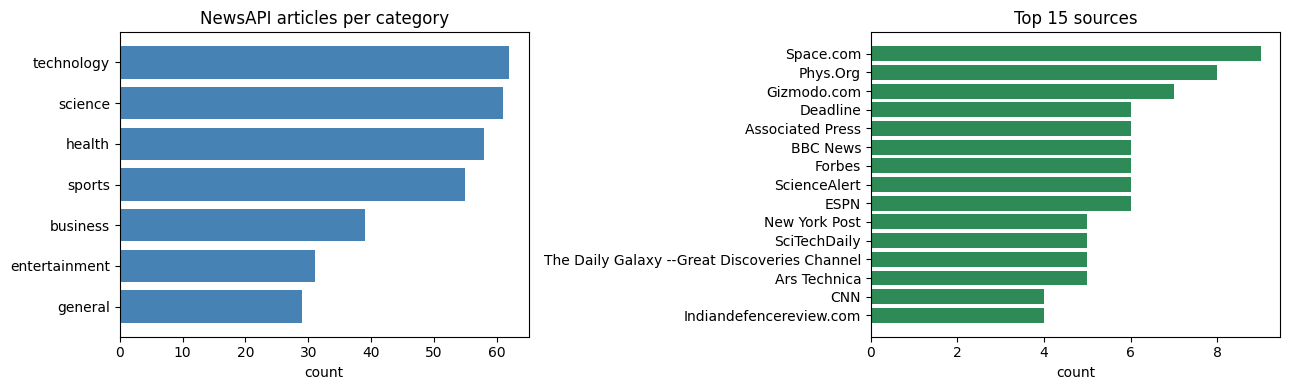

Unique sources: 201
Paywall-flagged: 6


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cat_counts = newsapi_df['category'].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='steelblue')
axes[0].set_title('NewsAPI articles per category')
axes[0].set_xlabel('count')

top_sources = newsapi_df['source'].value_counts().head(15)
axes[1].barh(top_sources.index[::-1], top_sources.values[::-1], color='seagreen')
axes[1].set_title('Top 15 sources')
axes[1].set_xlabel('count')

plt.tight_layout()
plt.show()

print(f'Unique sources: {newsapi_df["source"].nunique()}')
print(f'Paywall-flagged: {int(newsapi_df["is_paywall_preview"].sum())}')

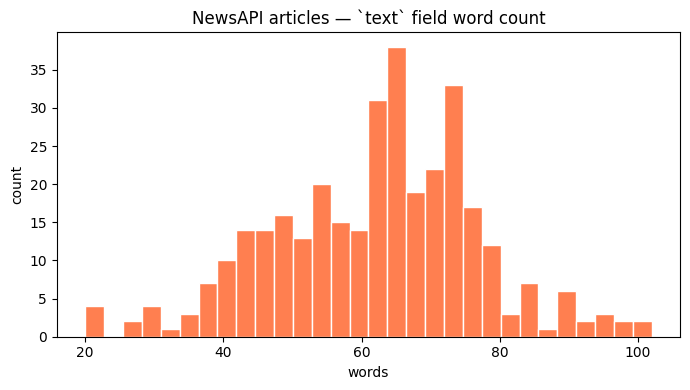

,min,p25,median,p75,p95,max,mean
0,20,52,63,72,84,102,61.8


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(newsapi_df['word_count'], bins=30, color='coral', edgecolor='white')
ax.set_title('NewsAPI articles — `text` field word count')
ax.set_xlabel('words')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

wc = newsapi_df['word_count']
pd.DataFrame([{
    'min': int(wc.min()), 'p25': int(wc.quantile(.25)),
    'median': int(wc.median()), 'p75': int(wc.quantile(.75)),
    'p95': int(wc.quantile(.95)), 'max': int(wc.max()),
    'mean': round(wc.mean(), 1)
}])

## 7. Findings Summary

### CNN/Daily Mail (15K sample)

**Length observations** (word counts):

| field | p50 | p75 | p90 | p95 | p99 |
|-------|-----|-----|-----|-----|-----|
| article | 512 | 777 | 1039 | 1231 | 1577 |
| highlights / summary_target | 45 | 53 | 64 | 74 | 98 |
| headline (derived) | 25 | 31 | 36 | 40 | 53 |

Implications for [config.yaml](../configs/config.yaml):
- **Article (input):** p95 = 1231 words → ~1500 BPE tokens. BART's `max_input_tokens: 1024` truncates, but this is standard for CNN/DM and acceptable.
- **Summary target (Stage 2 output):** p95 = 74 words → ~100 tokens. Current `stage2.max_output_tokens: 128` has healthy headroom. ✅
- **Headline (Stage 1 output):** p50 = 25 words ≈ 30–35 BPE tokens, p95 = 40 words ≈ 50+ tokens. `stage1.max_output_tokens` was raised from 30 → **48** to avoid clipping the median headline. ✅

**Zero newlines in articles.** CNN/DM v3.0.0 stores each article as a single paragraph. "First line" and "first sentence" were different concepts — we use sentence-boundary splitting.

**Prefix patterns** in the 15K sample:

| pattern | count | pct | stripped? |
|---------|-------|-----|-----------|
| `CITY (CNN) -- ` (dateline) | 2,383 | 15.9% | ✅ |
| `(CNN) -- ` (plain) | 2,057 | 13.7% | ✅ |
| `ALL-CAPS` opening (city-only, no paren) | 1,829 | 12.2% | ❌ (not stripped — standalone city names in headlines are legitimate) |
| `CITY, COUNTRY (Reuters) -- ` | 14 | 0.1% | ❌ (too rare to warrant a rule) |

The strip rule now covers **~29.6% of articles** (plain + CITY dateline). ALL-CAPS city openings (`WASHINGTON`, `LONDON`, etc.) without the `(CNN)` parenthetical are left intact because they often are legitimate datelines that belong in the headline.

### NewsAPI (335 cleaned articles)
- All 7 categories populated; **201 unique sources** → good diversity.
- `text` field word count: median 63, range 20–102. Sufficient for clustering via sentence embeddings; too short for full multi-doc summarization on its own (which is why Multi-News is the primary pipeline input).
- **6 paywall-preview flagged** articles (FT, Air Current, Vox, 2× NBC News, 404 Media).